In [ ]:
%pylab inline
%config InlineBackend.figure_format = 'retina'
from ipywidgets import interact
import scipy.stats as stats
import pandas as pd
# import pymc3 as pm
import arviz as az
import seaborn as sns

import tensorflow as tf
import tensorflow_probability as tfp
tfd = tfp.distributions
tfb = tfp.bijectors

import warnings # the warning spam is pointless and annoying
warnings.simplefilter(action="ignore", category=FutureWarning)

Populating the interactive namespace from numpy and matplotlib


# New Concept: Latent variables
We often have components of a system that are unobserved or unmeasured, yet are necessary to include in the generative model. Generally there are two situations
  1. We are interested in learning about these unobserved quantities (we will see examples of this today)
  2. Like in the wolf pack example, we want to "average" out the influence of these latent variables. In other words, we want to consider the influence of every possible combination of latent variables on what we know about the parameters.

Suppose we have data $Z$, latent $X$, and parameters $\theta$. From the Bayesian perspective, we might be interested in

  1. $\Pi(X \mid Z, \theta)$
  2. $\Pi(\theta \mid Z)$

### Question: how are "latent" variables different from parameters?
From the perspective of Bayes theorem, it is a distinction without a difference. From an inference perspective, latent variables grow in number as the amount of data grows, where parameters are fixed in number as the amount data grows.

# New Concept: time dependent models
How does time change the way we think about models?

## Example: A GPS tracking collar on a polar bear
There are no latent variables in this example (though maybe we should add them to model measurement error). Suppose that our GPS device is perfect. It gives us a time series of positions $Z_k$, $k=1, \ldots, T$. Suppose for simplicity that the measurements are taken at evenly space intervals. We denote the time series of measurements as $Z_{1:T}$. Suppose the polar bear moves by simple Brownian motion. Our generative model is
$$\begin{align*}
 Z_k &\sim \text{Normal}(Z_{k-1}, \sigma), \\
 \sigma &\sim \text{LogNormal}(0, 1)
\end{align*}
$$
We are interested in learning about $\sigma$. The parameter $\sigma$ is related to a "diffusion coefficient"
$$D = \frac{\sigma^2}{2},$$
 which tells us how quickly the polar bear explores territory. Note that $D$ has units of $\rm length^2/time$.

# State space models
Let us continue with our example about tracking polar bears. Suppose we now have data from a tracking collar of one of our bears. The GPS measurements that come from the collar are samples at equal time intervals of 1 hour. Our collar measurements will be given by
$$ z_{k} \sim \text{Normal}(x_{k}, \sigma_{\rm obs}),$$
where $x_{k}$ is the actual position of the bear at times $t_k = k$. We will model the actual position of the bear as a simple random walk
$$ x_k \sim \text{Normal}(x_{k-1}, \sigma)$$

The full generative model is then
\begin{align}
  z_{k} &\sim \text{Normal}(x_{k}, \sigma_{\rm obs}) \\
   x_k &\sim \text{Normal}(x_{k-1}, \sigma) \\
   x_0 & \sim  \text{Normal}(0, 25)\\
   \sigma_{\rm obs} &\sim \text{Exponential(1)} \\
   \sigma &\sim \text{Exponential(0.1)}
\end{align}

## State space model in Tensorflow
Since we assume the bear moves according to a Markov process, the steps are all independent, which means we can express the posterior as a product over each time index with
$$\pi(X_{0:T} \mid Z_{1:T}, \theta) = \pi(x_0, x_1, \ldots, x_T | z_1, \ldots, z_T; \theta) \propto p_0(x_0)\prod_{k=1}^{T}g(z_k| x_k)f(x_k | x_{k-1}).$$
The generative model is
$$p(X_{0:T} , Z_{1:T} \mid \theta) = p(x_0, x_1, \ldots, x_T, z_1, \ldots, z_T | \theta) = p_0(x_0)\prod_{k=1}^{T}g(z_k| x_k)f(x_k | x_{k-1}).$$


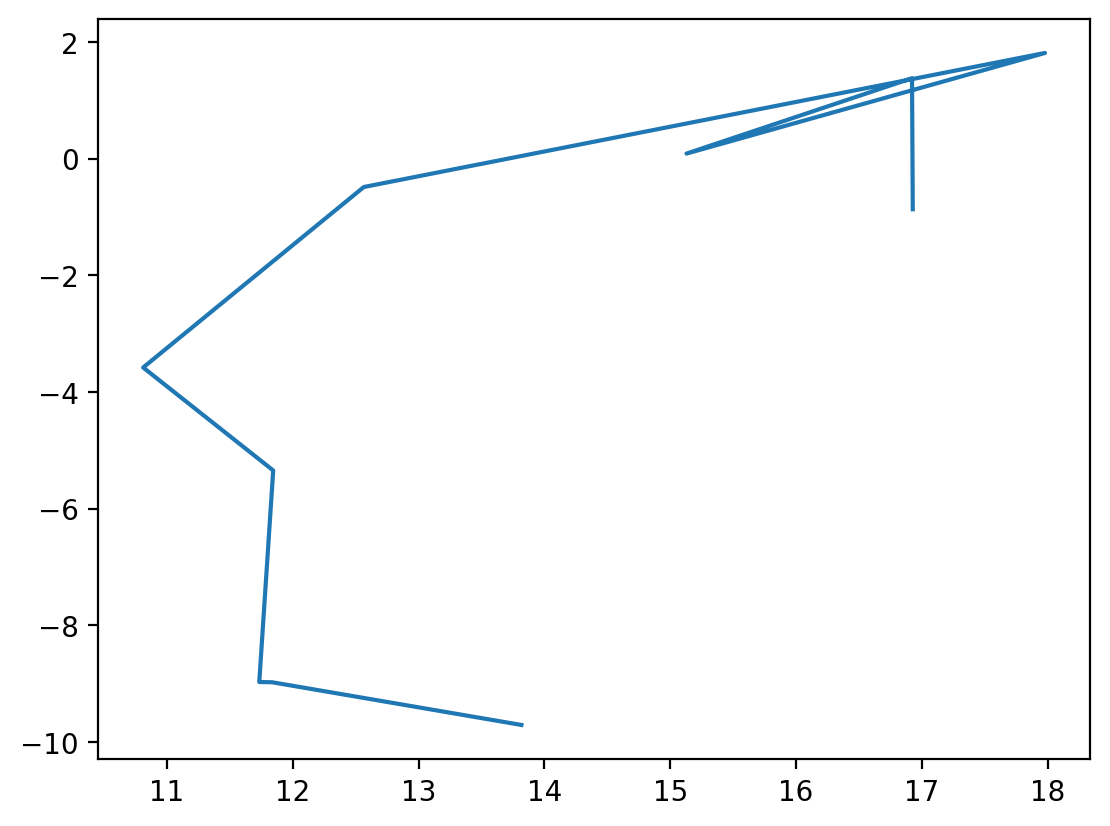

In [ ]:
### Simulate some data for our example
Nt = 10 ## number of measured positions from bear's trackinkg collar
sigma_obs = 0.2
sigma = 2.

X0true = -25. + 50.*rand(1, 2) ## bear's initial position
Xtrue = X0true + normal(0, sigma, [Nt, 2]).cumsum(axis=0)
Z = Xtrue + normal(0, sigma_obs, [Nt, 2]) ## add observation error to the path
plot(Z[:, 0], Z[:, 1]);

In [ ]:
Nsteps = 50
N_burn_in = Nsteps
Nchains = 2


Sigma_obs = sigma_obs*tf.ones([1, 1, 2], dtype=tf.float64)
Sigma = sigma*tf.ones([1, 1, 2], dtype=tf.float64)
Sigma_x0 = 100*tf.ones([1, 2], dtype=tf.float64)
def log_target_density(Xfull):
    ## X : [parallel chains, time, space]
    X0 = Xfull[:, 0, :]
    X = Xfull[:, 1:, :] ## same shape as `Z`
    ## observation likelihood: density for Z given X
    G = tfd.MultivariateNormalDiag(
        loc=X,
        scale_diag=Sigma_obs)
    logG = tf.reduce_sum(
        G.unnormalized_log_prob(Z),
        axis=1)
    ## motion model: density for X
    F = tfd.MultivariateNormalDiag(
        loc=Xfull[:, :-1, :],
        scale_diag=Sigma)
    logF = tf.reduce_sum(
        F.unnormalized_log_prob(X),
        axis=1)
    ## initial position prior: density for X0
    F0 = tfd.MultivariateNormalDiag(
        loc=tf.zeros([1, 2], dtype=tf.float64),
        scale_diag=Sigma_x0)
    logF0 = F0.unnormalized_log_prob(X0)
    return logG + logF + logF0

@tf.function()
def track_sampler(Xinit):
    #def trace_everything(states, previous_kernel_results):
    #    return previous_kernel_results

    kernel = tfp.mcmc.NoUTurnSampler(
        target_log_prob_fn=log_target_density,
        max_tree_depth=8,
        max_energy_diff=1000,
        step_size=tf.cast(0.1, tf.float64))

    # kernel = tfp.mcmc.HamiltonianMonteCarlo(
    #     target_log_prob_fn=log_target_density,
    #     num_leapfrog_steps=10,
    #     step_size=tf.cast(0.1, tf.float64))


    adaptive_kernel = tfp.mcmc.DualAveragingStepSizeAdaptation(
        inner_kernel=kernel,
        num_adaptation_steps=int(0.8 * N_burn_in),
        target_accept_prob=tf.cast(0.7, tf.float64))

    Xchain = tfp.mcmc.sample_chain(
        num_results=Nsteps,
        num_burnin_steps=N_burn_in,
        current_state=Xinit,
        #trace_fn=trace_everything,
        trace_fn=None,
        kernel=adaptive_kernel,
        parallel_iterations=4)
    return Xchain

Xinit = zeros([Nchains, Nt+1, 2])
Xinit[:, 0, :] = normal(0, 25., [Nchains, 2])
Xinit[:, 1:, :] = Z + normal(0, 5., [Nchains, Nt, 2])
Xchain = track_sampler(Xinit)
Xchain = array(Xchain)

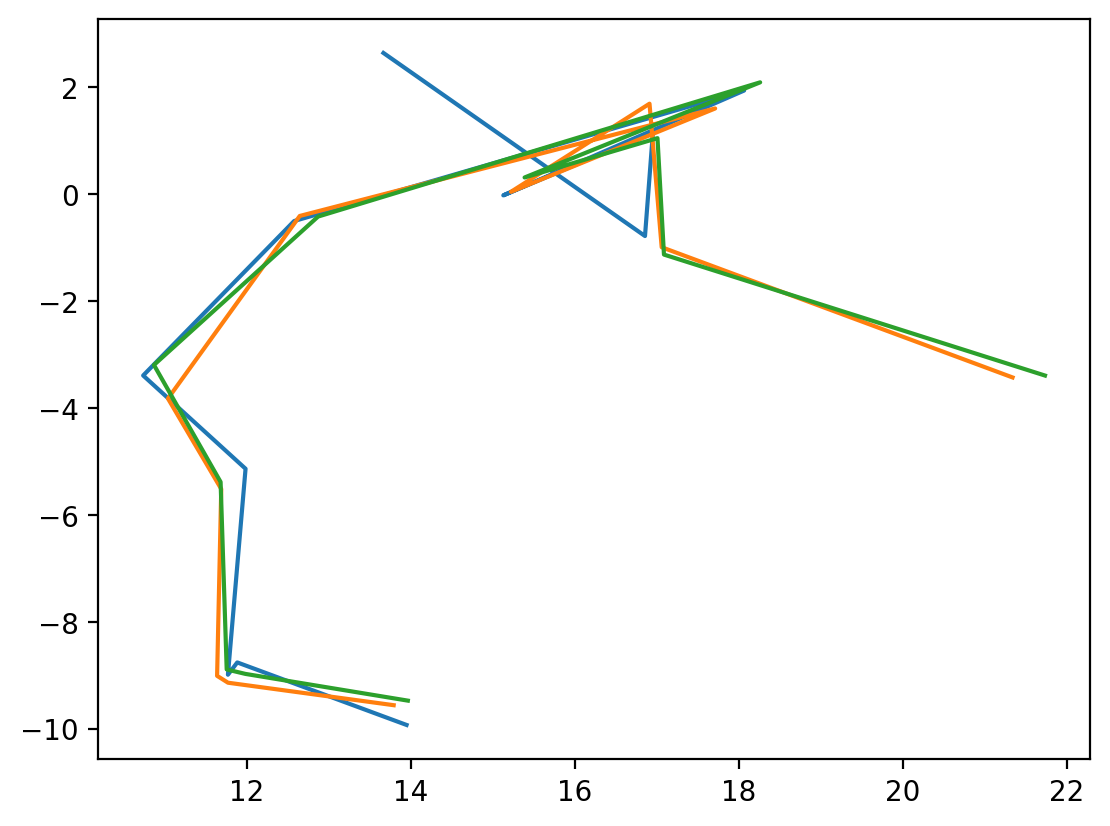

In [ ]:
plot(Xchain[-1, 0, :, 0], Xchain[-1, 0, :, 1])
plot(Xchain[-2, 0, :, 0], Xchain[-2, 0, :, 1])
plot(Xchain[-10, 0, :, 0], Xchain[-10, 0, :, 1])

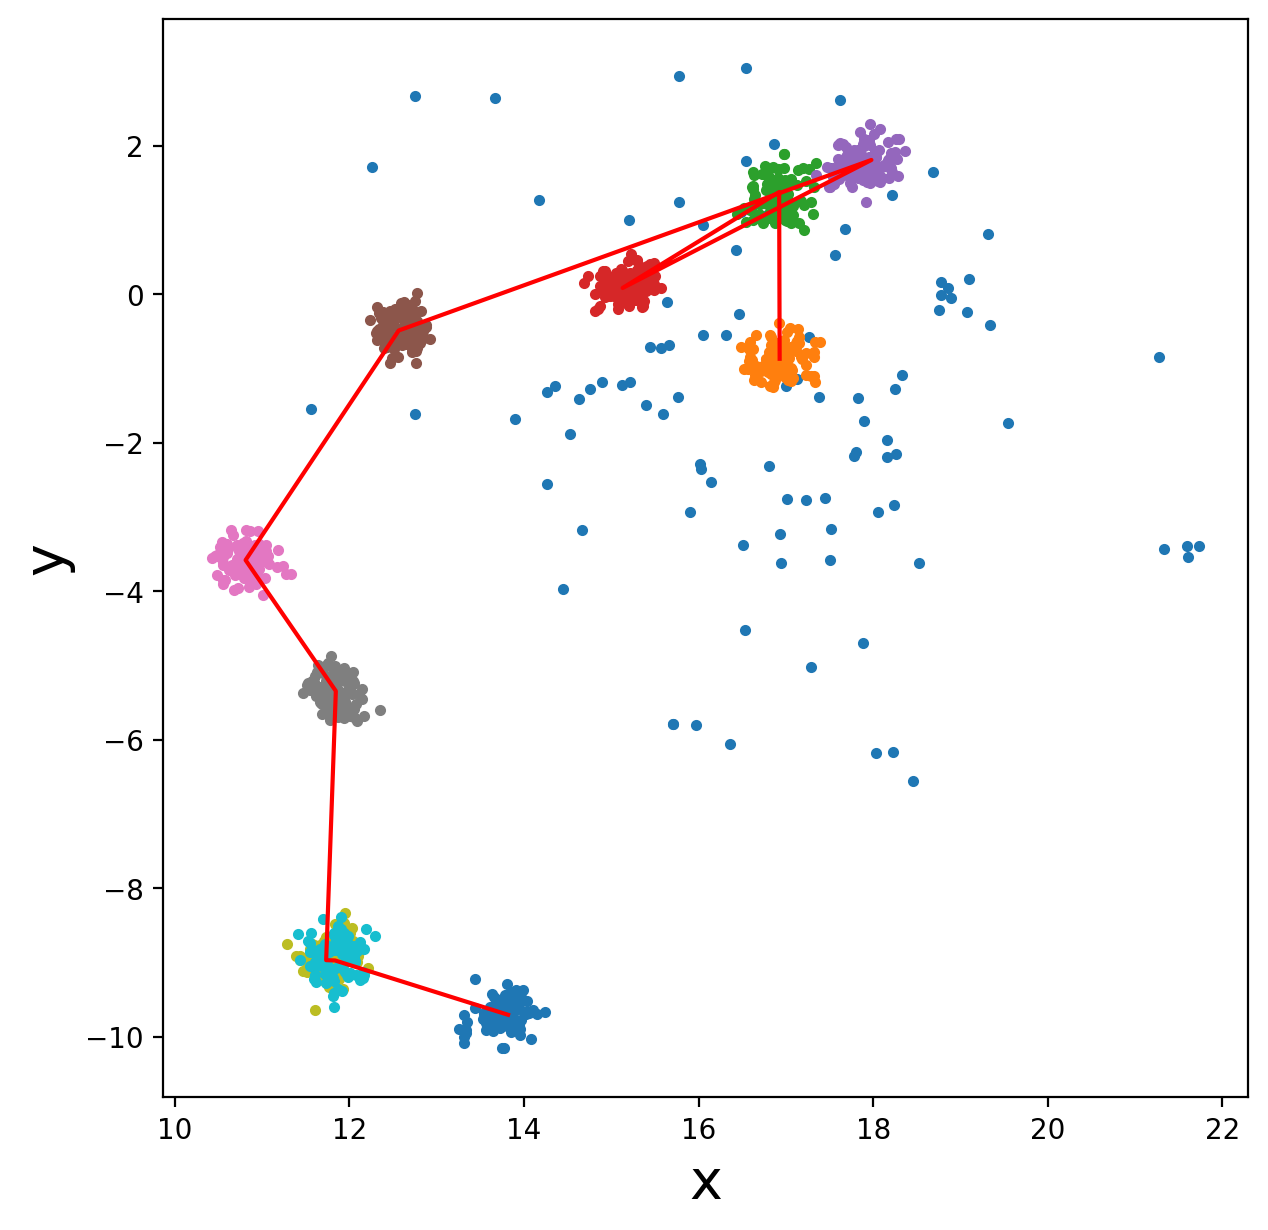

In [ ]:
figure(1, [7, 7])
## Xchain: [mcmc steps, parallel chains, time, space]
plot(Xchain[..., 0].reshape(-1, Nt+1), Xchain[..., 1].reshape(-1, Nt+1), '.')
plot(Z[:, 0], Z[:, 1], 'r')
xlabel('x', fontsize=20)
ylabel('y', fontsize=20);

# Suppose we want to sample $X$ at times that are in between the observation times

In [ ]:
Nt = 100
sigma_subsample = sigma/sqrt(10)

Zpadded = zeros([Nt, 2])
Zpadded[::10] = Z
### where Z is zero, we will modify our model so that these values of Z have no effect

## this is an indicator variable for when we have measured positions
CHI_observed = zeros([Nt])
CHI_observed[::10] = 1.

In [ ]:
Nsteps = 50
N_burn_in = Nsteps
Nchains = 5


Sigma_obs = sigma_obs*tf.ones([1, 1, 2], dtype=tf.float64)
Sigma = sigma_subsample*tf.ones([1, 1, 2], dtype=tf.float64)
Sigma_x0 = 100*tf.ones([1, 2], dtype=tf.float64)
def log_target_density(Xfull):
    ## X : [parallel chains, time, space]
    X0 = Xfull[:, 0, :]
    X = Xfull[:, 1:, :] ## same shape as `Z`
    ## observation likelihood: density for Z given X
    G = tfd.MultivariateNormalDiag(
        loc=X,
        scale_diag=Sigma_obs)
    logG = tf.reduce_sum(
        CHI_observed[None, :]*G.unnormalized_log_prob(Zpadded),
        axis=1)
    ## motion model: density for X
    F = tfd.MultivariateNormalDiag(
        loc=Xfull[:, :-1, :],
        scale_diag=Sigma)
    logF = tf.reduce_sum(
        F.unnormalized_log_prob(X),
        axis=1)
    ## initial position prior: density for X0
    F0 = tfd.MultivariateNormalDiag(
        loc=tf.zeros([1, 2], dtype=tf.float64),
        scale_diag=Sigma_x0)
    logF0 = F0.unnormalized_log_prob(X0)
    return logG + logF + logF0

@tf.function()
def track_sampler(Xinit):
    ## We are sampling a distribution over 200 dimensions

    kernel = tfp.mcmc.NoUTurnSampler(
        target_log_prob_fn=log_target_density,
        max_tree_depth=8,
        max_energy_diff=1000,
        step_size=tf.cast(0.1, tf.float64))

    # kernel = tfp.mcmc.HamiltonianMonteCarlo(
    #     target_log_prob_fn=log_target_density,
    #     num_leapfrog_steps=10,
    #     step_size=tf.cast(0.1, tf.float64))


    adaptive_kernel = tfp.mcmc.DualAveragingStepSizeAdaptation(
        inner_kernel=kernel,
        num_adaptation_steps=int(0.8 * N_burn_in),
        target_accept_prob=tf.cast(0.7, tf.float64))

    Xchain = tfp.mcmc.sample_chain(
        num_results=Nsteps,
        num_burnin_steps=N_burn_in,
        current_state=Xinit,
        #trace_fn=trace_everything,
        trace_fn=None,
        kernel=adaptive_kernel,
        parallel_iterations=4)
    return Xchain

Xinit = zeros([Nchains, Nt+1, 2])
Xinit[:, 0, :] = normal(0, 25., [Nchains, 2])
Xinit[:, 1:, :] = Zpadded + normal(0, 5., [Nchains, Nt, 2])
Xchain = track_sampler(Xinit)
Xchain = array(Xchain)

### This plot shows the MCMC result as a time series of marginal distributions for the position at time $t$

In [ ]:
xmin = Xchain.min()
xmax = Xchain.max()
@interact(t=(0, Nt, 1))
def pfun(t=0):
    fig = figure(1, [6, 6])
    plot(Xchain[:, :, t, 0], Xchain[:, :, t, 1], 'r.', ms=2)
    if t > 0 and CHI_observed[t-1] == 1:
        plot(Zpadded[t-1, 0], Zpadded[t-1, 1], 'ko', mfc='none', ms=25)
    xlim(xmin, xmax)
    ylim(xmin, xmax)
    xlabel(r'$x$', fontsize=24)
    ylabel(r'$y$', fontsize=24)
    show();

interactive(children=(IntSlider(value=0, description='t'), Output()), _dom_classes=('widget-interact',))

### This shows the MCMC result as a collection of sample trajectories
Each parallel chain (at a given step) represents an independent path $X_{0:T}$. Here each is shown as a different color.

In [ ]:
xmin = Xchain.min()
xmax = Xchain.max()
@interact(t=(0, Nt, 1))
def pfun(t=0):
    fig = figure(1, [6, 6])
    for i in arange(5):
        plot(Xchain[-1, i, t, 0], Xchain[-1, i, t, 1], '.', ms=10)
    if t > 0 and CHI_observed[t-1] == 1:
        plot(Zpadded[t-1, 0], Zpadded[t-1, 1], 'ko', mfc='none', ms=25)
    xlim(xmin, xmax)
    ylim(xmin, xmax)
    xlabel(r'$x$', fontsize=24)
    ylabel(r'$y$', fontsize=24)
    show();

interactive(children=(IntSlider(value=0, description='t'), Output()), _dom_classes=('widget-interact',))

# Expectation Maximization Algorithm
Suppose we want to compute maximum likelihood parameters for a model that has latent parameters. This is useful in the context of sampling since it can be an effective way to initialize a MCMC sampler. (A similar iterative procedure, called a Gibbs sampler, can be used to sample parameters and latent variables.)

To compute maximum likelihood parameters $\theta$ given data $Z_{1:T}$, we need the log likelihood function
$$L(\theta) := \log(p(Z_{1:T} \mid \theta)).$$
We can then obtain the maximum likelihood estimator
  $$\theta_{MLE} =  \text{arg max}_{\theta}L(\theta).$$




## What happens when we have latent variables $X_{0:T}$?
To get the log likelihood function, we need to marginalize the generative density over the latent variables; that is,
$$L(\theta) := \log(p(Z_{1:T} \mid \theta)) = \log(\int_R \cdots \int_R p(X_{0:T}, Z_{1:T} \mid \theta)\, dX_0\cdots dX_T ).$$
Unfortunately, the above is not simple to compute. We want a way that we can use samples of $X_{1:T} \mid Z_{1:T}, \theta$ (e.g., using our MCMC method above) to compute $L(\theta)$.

From the law of conditional probability, we have that
$$ p(Z_{1:T}\mid \theta)  = \frac{p(X_{0:T}, Z_{1:T} \mid \theta )}{\pi(X_{0:T} \mid Z_{1:T}, \theta)}.$$
  - The left hand side is the likelihood function we want
  - The numerator of the right hand side is the generative density (a known function)
  - The denominator is not explicitly know, but we can sample from this density using the MCMC procedure at the beginning of this notebook

We can then rewrite the log likelihood function as
$$L(\theta) = \log(p(Z_{1:T}\mid \theta)) = \log(p(X_{0:T}, Z_{1:T} \mid \theta )) - \log(\pi(X_{0:T} \mid Z_{1:T}, \theta)).$$
The next step is to take the expectation of the above with respect to $X_{0:T} \mid Z_{1:T},\theta'$ which has density function $\pi(X_{0:T} \mid Z_{1:T},\theta')$. Notice that $\theta'$ need not be equal to $\theta$.
Doing this yields
\begin{align}
&\int_R \cdots \int_R  p(X_{0:T} \mid Z_{1:T}, \theta') \log(p(Z_{1:T}\mid \theta)) \, dX_0\cdots dX_T \\
& \quad = \int_R \cdots \int_R \pi(X_{0:T} \mid Z_{1:T}, \theta')\log(p(X_{0:T}, Z_{1:T} \mid \theta' ))\, dX_0\cdots dX_T  \\
&\qquad - \int_R \cdots \int_R \pi(X_{0:T} \mid Z_{1:T}, \theta')\log(\pi(X_{0:T} \mid Z_{1:T}, \theta))\, dX_0\cdots dX_T .
\end{align}
Note that the $\log(p(Z_{1:T}\mid \theta))$ term in left hand side is independent of $X_{0:T}$ so we have
\begin{align}
 L(\theta) &= \log(p(Z_{1:T}\mid \theta)) \\
& = \int_R \cdots \int_R \pi(X_{0:T} \mid Z_{1:T}, \theta')\log(p(X_{0:T}, Z_{1:T} \mid \theta ))\, dX_0\cdots dX_T  \\
&\qquad - \int_R \cdots \int_R \pi(X_{0:T} \mid Z_{1:T}, \theta')\log(\pi(X_{0:T} \mid Z_{1:T}, \theta))\, dX_0\cdots dX_T \\
&= E[\log(p(X_{0:T}, Z_{1:T} \mid \theta )) \mid Z_{1:T}, \theta']
 - E[\log(\pi(X_{0:T} \mid  Z_{1:T}, \theta )) \mid Z_{1:T}, \theta'] \\
 & := Q(\theta \mid \theta') + H(\theta \mid \theta')
\end{align}
Note that it is not clear yet how we compute the second term on the right hand side, $H(\theta \mid \theta')$, since it requires the posterior $\pi(X_{0:T}\mid Z_{1:T}, \theta)$ which we do not know explicitly.

### How do we get rid of the $H(\theta \mid \theta')$ term?
By Gibb's inequality, we have that $H(\theta \mid \theta') \geq H(\theta' \mid \theta')$. Hence,
$$ L(\theta) \geq Q(\theta \mid \theta') + H(\theta' \mid \theta').$$

# Expectation-Maximization Algorithm
  1. E-step: given fixed parameters $\theta_j$ sample
  $$ X_{1:T} \mid Z_{1:T}, \theta_j$$
  Then plug them into the log generative density and average over the samples. This appproximates the expectation,
  \begin{align}
  Q(\theta | \theta_j) & := E[\log(p_0(X_0|\theta)\prod_{k=1}^{T}g(Z_k| X_k, \theta)f(X_k | X_{k-1}, \theta)) \mid Z_{1:T}, \theta_j]\\
  &= E[\log(p_0(X_0|\theta)) + \sum_{k=1}^{T}\log(g(Z_k| X_k, \theta)) + \sum_{k=1}^{T}\log(f(X_k | X_{k-1}, \theta)) \mid Z_{1:T}, \theta_j] \\
  &= E[\log(p_0(X_0|\theta))\mid Z_{1:T},\theta_j] + \sum_{k=1}^{T}E[\log(g(Z_k| X_k, \theta))\mid Z_{1:T},\theta_j] + \sum_{k=1}^{T}E[\log(f(X_k | X_{k-1}, \theta)) \mid Z_{1:T},\theta_j]
  \end{align}
  2. M-step: compute $$\theta_{j+1} = \text{arg max}_{\theta} Q(\theta | \theta_j)  $$
  
Repeat these steps until convergence is reached.

# Expectation Maximization with Tensorflow gradient descent
Suppose we want to estimate the bear's mobility parameter $\sigma$

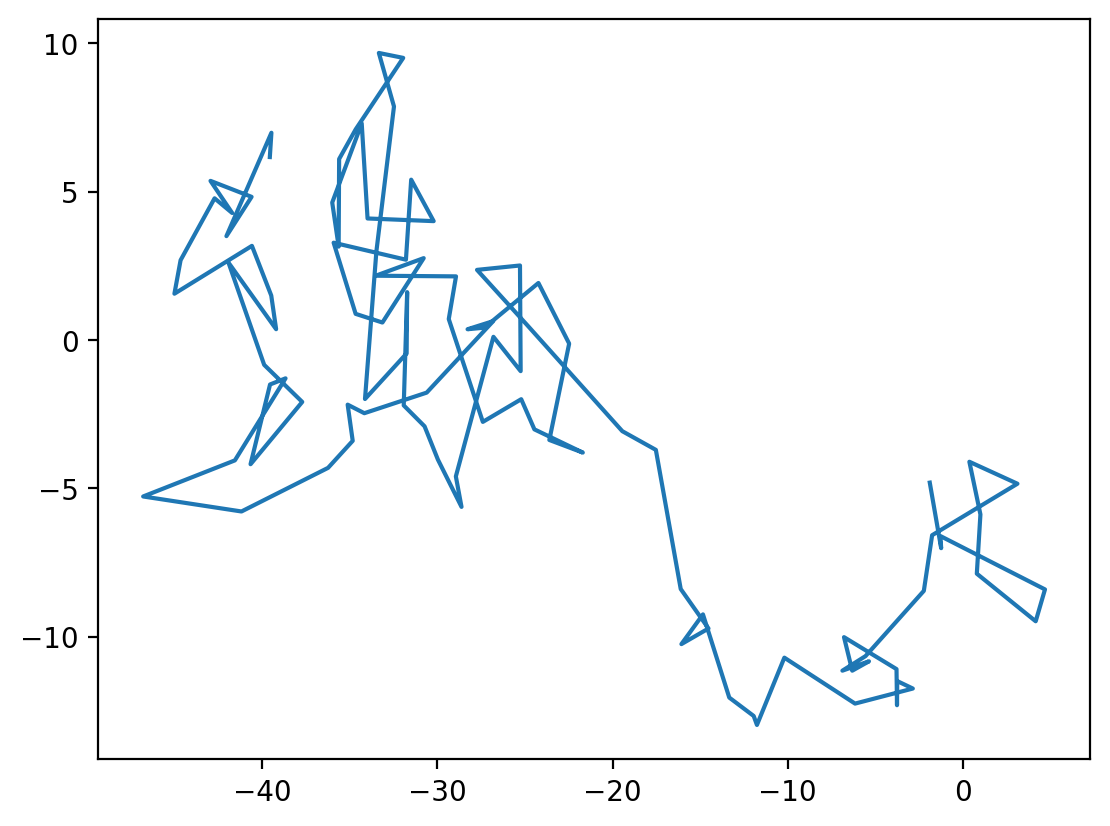

In [ ]:
Nt = 100 ## number of measured positions from bear's tracking collar
sigma_obs = 0.2
sigma = 2.

X0true = -25. + 50.*rand(1, 2) ## bear's initial position
Xtrue = X0true + normal(0, sigma, [Nt, 2]).cumsum(axis=0)
Z = Xtrue + normal(0, sigma_obs, [Nt, 2]) ## add observation error to the path
plot(Z[:, 0], Z[:, 1]);

In [ ]:
Nsteps = 10 ## number of MCMC steps
N_burn_in = 50
Nchains = 8

log_sigma_obs = tf.Variable(log(1.), dtype=tf.float64)
log_sigma = tf.Variable(log(5.), dtype=tf.float64)

@tf.function()
def log_target_density(Xfull):
    ## Xfull must be a three dimensional array
    Sigma_obs = tf.math.exp(log_sigma_obs)*tf.ones([1, 1, 2], dtype=tf.float64)
    ## tensorflow variable appears here
    Sigma = tf.math.exp(log_sigma)*tf.ones([1, 1, 2], dtype=tf.float64)
    Sigma_x0 = 100*tf.ones([1, 2], dtype=tf.float64)
    ## X : [parallel chains, time, space]
    X0 = Xfull[:, 0, :]
    X = Xfull[:, 1:, :] ## same shape as `Z`
    ## observation likelihood: density for Z given X
    G = tfd.MultivariateNormalDiag(
        loc=X,
        scale_diag=Sigma_obs)
    logG = tf.reduce_sum(
        G.unnormalized_log_prob(Z),
        axis=1)
    ## motion model: density for X
    F = tfd.MultivariateNormalDiag(
        loc=Xfull[:, :-1, :],
        scale_diag=Sigma)
    logF = tf.reduce_sum(
        F.unnormalized_log_prob(X),
        axis=1)
    ## initial position prior: density for X0
    F0 = tfd.MultivariateNormalDiag(
        loc=tf.zeros([1, 2], dtype=tf.float64),
        scale_diag=Sigma_x0)
    logF0 = F0.unnormalized_log_prob(X0)
    return logG + logF + logF0

@tf.function()
def track_sampler(Xinit):
    kernel = tfp.mcmc.NoUTurnSampler(
        target_log_prob_fn=log_target_density,
        max_tree_depth=8,
        max_energy_diff=1000,
        step_size=tf.cast(0.1, tf.float64))

    adaptive_kernel = tfp.mcmc.DualAveragingStepSizeAdaptation(
        inner_kernel=kernel,
        num_adaptation_steps=int(0.8 * N_burn_in),
        target_accept_prob=tf.cast(0.7, tf.float64))

    Xchain = tfp.mcmc.sample_chain(
        num_results=Nsteps,
        num_burnin_steps=N_burn_in,
        current_state=Xinit,
        #trace_fn=trace_everything,
        trace_fn=None,
        kernel=adaptive_kernel,
        parallel_iterations=4)
    return Xchain


In [ ]:
## Estep

def Estep():
    Xinit = zeros([Nchains, Nt+1, 2])
    Xinit[:, 0, :] = normal(0, 25., [Nchains, 2])
    Xinit[:, 1:, :] = Z + normal(0, 5., [Nchains, Nt, 2])
    Xchain = track_sampler(Xinit)
    Xchain = array(Xchain)
    return Xchain ## [MCMC steps, parallel chains, time, space]

@tf.function()
def averaged_log_density():
    X_reshaped = Xchain.reshape(-1, Nt+1, 2)
    return tf.reduce_mean(log_target_density(X_reshaped))

In [ ]:
## M step

N_gd_steps = 50
learning_rate = 0.001
optimizer = tf.optimizers.SGD(learning_rate=learning_rate)
# learning_rate = 0.01
# optimizer = tf.optimizers.Adam(learning_rate=learning_rate)
trainable_variables = [log_sigma, log_sigma_obs]

@tf.function()
def Mstep(Xchain):
    loss = tf.constant(0., dtype=tf.float64)
    for _ in tf.range(N_gd_steps):
        with tf.GradientTape() as tape:
            ## must tell Tensorflow what trainable variables to use for
            ## gradients
            tape.watch(trainable_variables)
            ## we use the negative averaged log likelihood because our
            ## optimizer is set up to solve mimimization
            loss = -averaged_log_density()
        ## compute the gradient of the loss
        grad = tape.gradient(loss, trainable_variables)
        ## this takes one step of gradient descent to change the trainable
        ## prameters
        optimizer.apply_gradients(
            zip(grad, trainable_variables))
        ## Note that the values stored in the trainable variable object changes
        ## as a result of this operation
    return loss

In [ ]:
log_sigma.assign(log(4.)), log_sigma_obs.assign(log(.2))
print('sigma:', exp(log_sigma), 'sigma_obs:', exp(log_sigma_obs))
for _ in arange(20):
    Xchain = Estep()
    loss = Mstep(Xchain)
    print('loss:', array(loss))
    print('sigma:', exp(log_sigma), 'sigma_obs:', exp(log_sigma_obs))

sigma: 4.0 sigma_obs: 0.2
loss: 740.9012459154325
sigma: 2.3571385661535933 sigma_obs: 0.9549710226675304
loss: 740.9012459154324
sigma: 2.3571385661288113 sigma_obs: 0.9549710141809914
loss: 740.9012459154324
sigma: 2.3571385661288113 sigma_obs: 0.9549710141809914
loss: 740.9012459154324
sigma: 2.3571385661288113 sigma_obs: 0.9549710141809913
loss: 740.9012459154324
sigma: 2.3571385661288113 sigma_obs: 0.9549710141809914
loss: 740.9012459154324
sigma: 2.3571385661288113 sigma_obs: 0.9549710141809914
loss: 740.9012459154324
sigma: 2.3571385661288113 sigma_obs: 0.9549710141809914
loss: 740.9012459154324
sigma: 2.3571385661288113 sigma_obs: 0.9549710141809914
loss: 740.9012459154324
sigma: 2.3571385661288113 sigma_obs: 0.9549710141809914
loss: 740.9012459154324
sigma: 2.3571385661288113 sigma_obs: 0.9549710141809914
loss: 740.9012459154324
sigma: 2.3571385661288113 sigma_obs: 0.9549710141809913
loss: 740.9012459154324
sigma: 2.3571385661288113 sigma_obs: 0.9549710141809914
loss: 740.9012

In [ ]:
%pylab inline
%config InlineBackend.figure_format = 'retina'
from ipywidgets import interact
import ipywidgets as widgets
from IPython.display import display, HTML
import os
import pandas as pd
import time
import tempfile
import subprocess
from PIL import Image
from io import BytesIO
import base64

import tensorflow as tf
import tensorflow_probability as tfp

# matplotlib.style.use('ggplot')

def make_uint8(img):
    img = (img-img.min())/(img.max()-img.min())
    return uint8(255*img)

def MatplotlibVideo(vid, shape, filename, frameRate=10):
    """Make a web friendly compressed video. Input 'vid' is an iterator of PIL image objects."""
    NF, Ny, Nx = shape
    #with tempfile.NamedTemporaryFile(mode='w+b', suffix='.mp4') as tmpfile:
    with open(filename, mode='w+b') as tmpfile:
        cmdstring = ('ffmpeg', '-y',
                     '-r', '%d' % frameRate,
                     '-i', 'pipe:',
                     '-vcodec', 'libx264',
                     '-b:v',  '1000K',
                     '-crf', '22',
                     '-s', '{0}x{1}'.format(Nx, Ny),
                     '-pix_fmt', 'yuv420p',
                     tmpfile.name)
        proc = subprocess.Popen(cmdstring, stdin=subprocess.PIPE, shell=False)
        for img in vid:
            f = BytesIO()
            img.save(f, 'bmp')
            proc.stdin.write(f.getvalue())
        proc.stdin.close()
        proc.wait()
        encodedData = base64.standard_b64encode(tmpfile.read()).decode(errors='ignore')
        #tmpfile.read().decode('utf-8').encode('base64')
    vstring = '<video width="{0}" height="{1}" '
    vstring += 'controls autoplay loop src="data:video/mp4;base64,{2}">'
    return HTML(data = vstring.format(Nx//4, Ny//4, encodedData))